# Music Recommendation Algorithm - Data Cleaning, Wrangling & Preprocessing

Author: Nick Peril  
Project: TKH Technology Fellowship Portfolio Project

### Objectives:
To clean and pre-process the dataset in preparation for modeling.

---

### Importing libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Loading the datasets:

In [2]:
train_df = pd.read_csv("/Users/saadult/music-reco/data/raw_data/train.csv")
recommend_df = pd.read_csv("/Users/saadult/music-reco/data/raw_data/recommend.csv")

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

In [4]:
recommend_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                10 non-null     int64  
 1   artist_name               10 non-null     object 
 2   track_name                10 non-null     object 
 3   release_date              10 non-null     int64  
 4   genre                     10 non-null     object 
 5   lyrics                    10 non-null     object 
 6   len                       10 non-null     int64  
 7   dating                    10 non-null     float64
 8   violence                  10 non-null     float64
 9   world/life                10 non-null     float64
 10  night/time                10 non-null     float64
 11  shake the audience        10 non-null     float64
 12  family/gospel             10 non-null     float64
 13  romantic                  10 non-null     float64
 14  communication

The `recommend_df` dataset contains one extra column -- `like/girls`, that is not present in `train_df`. Since the model should be trained and tested using the same set of features, I will have to drop this column from `recommend_df` to keep both datasets consistent.

---

### Dropping unnecessary columns:
For modeling, I will be dropping columns that are identifiers or raw text.

In [5]:
columns_to_drop = [
    "Unnamed: 0",
    "artist_name",
    "track_name",
    "lyrics",
    "release_date"
]

# Dropping non-modeling columns from train_df
train_clean = train_df.drop(columns=columns_to_drop, errors="ignore")

# Dropping the same non-modeling columns plus the extra recommend_df-only column
recommend_clean = recommend_df.drop(
    columns=columns_to_drop + ["like/girls"],
    errors="ignore"
)

<u>Why dropping these columns?</u>
* `artist_name` and `track_name` identify songs but do not help clustering directly.
* `lyrics` is raw text and should be dropped for the main project.  
* `Unnamed: 0` is just an old index column and has no meaning, it does not describe the songs themselves.
* `release_date` is strongly correlated with `age`. Keeping both could give too much weight to the same time-related information during distance-based modeling.
* Again `like/girls` in `recommend_df` dataset has to be dropped to keep both dataset consistent especially in training and testing the model.

---

### Standardizing column names:
Since some columns have spaces and special characters like `world/life`, `night/time`, `shake the audience`, `movement/places`, `light/visual perceptions`, `family/spiritual`, it is better to clean the column names so they follow a consistent naming convention.

In [6]:
# Standardizing column names for cleaner and more consistent naming
# Defining a reusable function for cleaning column names
def clean_column_names(df):
    df = df.copy()                                      # Creates a copy so the original DataFrame is not changed directly
    df.columns = (
        df.columns
        .str.strip()                                    # Removes extra spaces at the beginning/end
        .str.lower()                                    # Converts all column names to lowercase
        .str.replace(" ", "_", regex=False)             # Replaces spaces with underscores
        .str.replace("/", "_", regex=False)             # Replaces slashes with underscores
        .str.replace("[^a-z0-9_]", "", regex=True)      # Removes any remaining special characters
    )
    return df

train_clean = clean_column_names(train_clean)
recommend_clean = clean_column_names(recommend_clean)

I standardized the column names by converting them to lowercase and replacing spaces or special characters with underscores. This makes the dataset easier to work with and follows a cleaner naming convention for Python code. Let's see how they look now:

In [7]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   genre                     28362 non-null  object 
 1   len                       28362 non-null  int64  
 2   dating                    28362 non-null  float64
 3   violence                  28362 non-null  float64
 4   world_life                28362 non-null  float64
 5   night_time                28362 non-null  float64
 6   shake_the_audience        28362 non-null  float64
 7   family_gospel             28362 non-null  float64
 8   romantic                  28362 non-null  float64
 9   communication             28362 non-null  float64
 10  obscene                   28362 non-null  float64
 11  music                     28362 non-null  float64
 12  movement_places           28362 non-null  float64
 13  light_visual_perceptions  28362 non-null  float64
 14  family

In [8]:
recommend_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   genre                     10 non-null     object 
 1   len                       10 non-null     int64  
 2   dating                    10 non-null     float64
 3   violence                  10 non-null     float64
 4   world_life                10 non-null     float64
 5   night_time                10 non-null     float64
 6   shake_the_audience        10 non-null     float64
 7   family_gospel             10 non-null     float64
 8   romantic                  10 non-null     float64
 9   communication             10 non-null     float64
 10  obscene                   10 non-null     float64
 11  music                     10 non-null     float64
 12  movement_places           10 non-null     float64
 13  light_visual_perceptions  10 non-null     float64
 14  family_spirit

Column names are now standardized for easier referencing. Also, `train_clean` and `recommend_clean` datasets are now matched in terms of the columns they have.

---

### Encoding categorical variables:
I have categorical columns such as `genre` and `topic`. I have to encode these into numeric format using one-hot encoding for modeling.

In [9]:
# One-hot encoding the genre and topic columns in the train dataset
train_encoded = pd.get_dummies(train_clean, columns=["genre", "topic"], drop_first=True)

# One-hot encoding the genre and topic columns in the recommend dataset
recommend_encoded = pd.get_dummies(recommend_clean, columns=["genre", "topic"], drop_first=True)

# Standardizing column names after encoding because new dummy columns may contain spaces or special characters
train_encoded = clean_column_names(train_encoded)
recommend_encoded = clean_column_names(recommend_encoded)

In [10]:
train_encoded.head()

,len,dating,violence,world_life,night_time,shake_the_audience,family_gospel,romantic,communication,obscene,...,genre_pop,genre_reggae,genre_rock,topic_music,topic_night_time,topic_obscene,topic_romantic,topic_sadness,topic_violence,topic_world_life
0,95,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,...,True,False,False,False,False,False,False,True,False,False
1,51,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,...,True,False,False,False,False,False,False,False,False,True
2,24,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,...,True,False,False,True,False,False,False,False,False,False
3,54,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,...,True,False,False,False,False,False,True,False,False,False
4,48,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,...,True,False,False,False,False,False,True,False,False,False


In [11]:
recommend_encoded.head()

,len,dating,violence,world_life,night_time,shake_the_audience,family_gospel,romantic,communication,obscene,...,genre_country,genre_jazz,genre_pop,genre_reggae,genre_rock,topic_obscene,topic_romantic,topic_sadness,topic_violence,topic_world_life
0,74,0.000907,0.348191,0.375448,0.000907,0.225414,0.000907,0.000907,0.000907,0.000907,...,False,False,False,False,True,False,False,False,False,True
1,43,0.001224,0.029943,0.001224,0.306688,0.001224,0.033440,0.069637,0.426669,0.001224,...,False,False,False,True,False,False,False,False,False,False
2,54,0.001120,0.482490,0.001120,0.001120,0.001120,0.113651,0.001120,0.001120,0.001120,...,False,False,True,False,False,False,False,False,True,False
3,25,0.204740,0.002506,0.002506,0.129818,0.002506,0.002506,0.002506,0.002506,0.002506,...,False,False,True,False,False,False,False,True,False,False
4,97,0.001170,0.001170,0.001170,0.050289,0.001170,0.023530,0.541449,0.001170,0.001170,...,False,False,True,False,False,False,True,False,False,False


After encoding, I have to align the columns so both datasets have the same features:

In [12]:
recommend_encoded = recommend_encoded.reindex(
    columns=train_encoded.columns,  # Matches recommend_encoded columns to the same columns in train_encoded
    fill_value=0  # Fills any missing columns with 0 if they exist in train_encoded but not in recommend_encoded
)

This is important because `train_encoded` and `recommend_encoded` may not have exactly the same genre/topic categories after one-hot encoding. This makes sure both dataset has the same feature columns and order which is important for scaling or using the recommendation model.

---

### Scaling the data:
KMeans is distance-based, so scaling is required.

In [13]:
# Creating a StandardScaler object to standardize the feature values
scaler = StandardScaler()

# Fitting the scaler on the train_encoded data and transforms it
# This learns the mean and standard deviation from train_encoded
train_scaled = scaler.fit_transform(train_encoded)  

# Transforming the recommen_encoded data using the same scaler from the train_encoded data
# This keeps both datasets scaled consistently
recommend_scaled = scaler.transform(recommend_encoded)

In [14]:
# Converting the scaled training data back into a DataFrame
train_scaled_df = pd.DataFrame(
    train_scaled,
    columns=train_encoded.columns
)

# Converting the scaled recommendation data back into a DataFrame
recommend_scaled_df = pd.DataFrame(
    recommend_scaled,
    columns=recommend_encoded.columns
)

Checking the summary statistics for both:

In [15]:
# Checking the scaled training data
train_scaled_df.describe().round(2)

,len,dating,violence,world_life,night_time,shake_the_audience,family_gospel,romantic,communication,obscene,...,genre_pop,genre_reggae,genre_rock,topic_music,topic_night_time,topic_obscene,topic_romantic,topic_sadness,topic_violence,topic_world_life
count,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,...,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00
mean,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.72,-0.40,-0.66,-0.70,-0.51,-0.42,-0.40,-0.46,-0.70,-0.53,...,-0.57,-0.31,-0.41,-0.30,-0.26,-0.46,-0.24,-0.52,-0.50,-0.49
25%,-0.74,-0.39,-0.66,-0.70,-0.50,-0.40,-0.38,-0.45,-0.69,-0.53,...,-0.57,-0.31,-0.41,-0.30,-0.26,-0.46,-0.24,-0.52,-0.50,-0.49
50%,-0.24,-0.38,-0.65,-0.66,-0.50,-0.39,-0.37,-0.44,-0.68,-0.53,...,-0.57,-0.31,-0.41,-0.30,-0.26,-0.46,-0.24,-0.52,-0.50,-0.49
75%,0.48,-0.33,0.42,0.45,0.08,-0.18,-0.29,-0.06,0.51,-0.05,...,-0.57,-0.31,-0.41,-0.30,-0.26,-0.46,-0.24,-0.52,-0.50,-0.49
max,3.01,11.97,4.83,4.88,8.19,11.81,12.59,8.41,5.20,4.94,...,1.74,3.22,2.46,3.36,3.82,2.19,4.20,1.91,1.99,2.06


In [16]:
# Checking the scaled recommendation data
recommend_scaled_df.describe().round(2)

,len,dating,violence,world_life,night_time,shake_the_audience,family_gospel,romantic,communication,obscene,...,genre_pop,genre_reggae,genre_rock,topic_music,topic_night_time,topic_obscene,topic_romantic,topic_sadness,topic_violence,topic_world_life
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,...,10.00,10.00,10.00,10.0,10.00,10.00,10.00,10.00,10.00,10.00
mean,-0.14,0.10,0.40,-0.18,0.79,0.28,0.02,0.14,0.76,-0.28,...,0.35,0.04,0.17,-0.3,-0.26,-0.19,0.21,-0.04,0.25,-0.23
std,0.91,1.23,1.36,0.69,1.48,1.72,0.85,1.60,1.70,0.80,...,1.20,1.12,1.21,0.0,0.00,0.84,1.40,1.03,1.20,0.80
min,-1.15,-0.39,-0.66,-0.70,-0.50,-0.41,-0.39,-0.45,-0.69,-0.53,...,-0.57,-0.31,-0.41,-0.3,-0.26,-0.46,-0.24,-0.52,-0.50,-0.49
25%,-0.75,-0.38,-0.65,-0.69,-0.39,-0.40,-0.38,-0.45,-0.69,-0.53,...,-0.57,-0.31,-0.41,-0.3,-0.26,-0.46,-0.24,-0.52,-0.50,-0.49
50%,-0.42,-0.38,-0.57,-0.36,0.30,-0.39,-0.37,-0.44,-0.05,-0.53,...,-0.57,-0.31,-0.41,-0.3,-0.26,-0.46,-0.24,-0.52,-0.50,-0.49
75%,0.33,-0.37,1.85,0.07,1.75,-0.14,0.03,-0.36,2.05,-0.53,...,1.74,-0.31,-0.41,-0.3,-0.26,-0.46,-0.24,-0.52,1.37,-0.49
max,1.89,3.51,2.38,1.48,3.89,5.12,2.30,4.65,3.51,2.00,...,1.74,3.22,2.46,-0.3,-0.26,2.19,4.20,1.91,1.99,2.06


To confirm that scaling was applied, I converted the scaled arrays back into DataFrames and checked their summary statistics. The train data should have feature means close to 0 and standard deviations close to 1 because the scaler was fitted on `train_encoded`. The recommendation data was transformed using the same scaler, so it is scaled consistently with the training data.

---

### PCA dimentionality reduction:
I use PCA, or Principal Component Analysis, to reduce the number of features while keeping as much important information as possible. PCA will help to visualize the songs in two dimensions so I can better understand whether songs with similar lyrical and genre features are grouping together before applying clustering.

In [17]:
# Creating a PCA object with 2 components so the data can be visualized in 2D
pca = PCA(n_components=2)

# Fitting PCA on the scaled train data and transform it into 2 principal components
train_pca = pca.fit_transform(train_scaled)

# Transforming the scaled recommend data using the same PCA model
recommend_pca = pca.transform(recommend_scaled)

# Converting the PCA result for the training data into a DataFrame for easier viewing and plotting
pca_df = pd.DataFrame(
    train_pca,
    columns=["PC1", "PC2"]
)

# Displaying the first few rows of the PCA DataFrame
pca_df.head()

# Checking how much variance is explained by each principal component
pca.explained_variance_ratio_

array([0.10254006, 0.08105025])

The first two principal components explain about 18.36% of the total variance in the dataset. This means the 2D PCA view captures some of the overall feature patterns, but not all of the information, so it should mainly be used for visualization rather than as the full basis for modeling.

I color-coded the PCA plot by topic to check whether songs with similar lyrical themes appear closer together. This helps show if topic-based patterns may be useful for clustering and recommendation modeling.

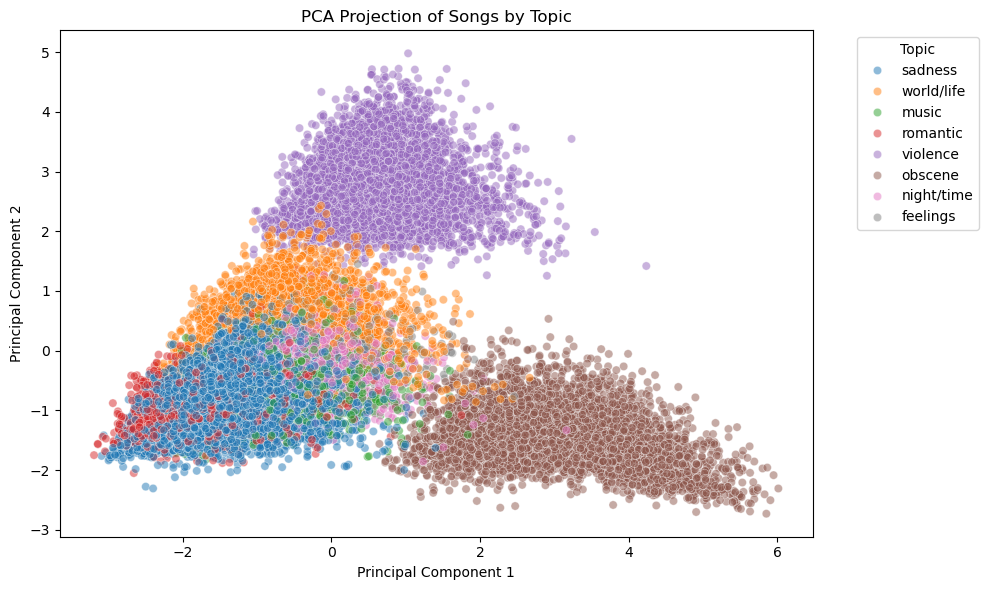

In [18]:
# Adding the original topic labels to the PCA DataFrame for color-coding
pca_df["topic"] = train_df["topic"].values

# Creating a scatter plot of the songs using the first two principal components
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="topic",      # Colors the points based on lyrical topic
    alpha=0.5         # Makes points slightly transparent so overlapping points are easier to see
)

# Adding chart title and axis labels
plt.title("PCA Projection of Songs by Topic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Moving the legend outside the chart so it does not cover the points
plt.legend(
    title="Topic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Adjusting spacing so all chart elements fit properly
plt.tight_layout()

# Saving the PCA scatter plot as an image file
plt.savefig("../docs/images/pca_scatter_by_topic.png")

# Displaying the chart
plt.show()

The PCA plot shows that songs with similar topics form some visible groupings, especially topics like violence and obscene, which appear more separated from the others. However, there is still overlap between several topics, meaning the first two principal components only give a simplified view of the data. This suggests that topic-based features may be useful for clustering, but the final model should still rely on the full scaled feature set.

---

### Final shape check:
Before saving the transformed datasets, I just want to confirm that both have the expected number of rows and columns.

In [19]:
# Checking the shape of the final scaled datasets
print("Train scaled shape:", train_scaled_df.shape)
print("Recommend scaled shape:", recommend_scaled_df.shape)

Train scaled shape: (28362, 30)
Recommend scaled shape: (10, 30)


Great! both datasets have the same number of columns: 30.

Checking final feature list:

In [23]:
# Displaying the final feature columns used for modeling
train_scaled_df.columns.tolist()

['len',
 'dating',
 'violence',
 'world_life',
 'night_time',
 'shake_the_audience',
 'family_gospel',
 'romantic',
 'communication',
 'obscene',
 'music',
 'movement_places',
 'light_visual_perceptions',
 'family_spiritual',
 'sadness',
 'feelings',
 'age',
 'genre_country',
 'genre_hip_hop',
 'genre_jazz',
 'genre_pop',
 'genre_reggae',
 'genre_rock',
 'topic_music',
 'topic_night_time',
 'topic_obscene',
 'topic_romantic',
 'topic_sadness',
 'topic_violence',
 'topic_world_life']

In [24]:
# Confirming that train and recommend datasets have the same final feature columns
train_scaled_df.columns.equals(recommend_scaled_df.columns)

True

---

### Saving transformed datasets:

In [26]:
train_encoded.to_csv("../data//clean_data/train_cleaned.csv", index=False)
recommend_encoded.to_csv("../data/clean_data/recommend_cleaned.csv", index=False)

---

### Summary:
In this notebook, the raw train and recommend datasets were cleaned and prepared for modeling. Unnecessary columns such as identifiers, raw lyrics, old index columns, and redundant time-related features were removed to keep only useful modeling features. The extra `like/girls` column in the recommendation dataset was also dropped so both datasets could stay consistent.

Column names were standardized by converting them to lowercase and replacing spaces or special characters with underscores. Categorical columns such as `genre` and `topic` were then one-hot encoded so they could be used by machine learning models. After encoding, the recommendation dataset was reindexed to match the training dataset’s columns and feature order.

The features were scaled using `StandardScaler` because KMeans is distance-based and requires features to be on a similar scale. PCA was also applied to reduce the scaled data into two principal components for visualization. The PCA plot showed some topic-based grouping patterns, although there was still overlap, so PCA was mainly used as an exploratory visualization rather than the final modeling input.

Final validation checks confirmed that both transformed datasets have matching feature columns and are ready for the modeling phase.